# Q1. full_Data load karo aur shape, dtypes, missing values count karo har column mein

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('datasets/full_Data.csv')

print("\nShape of fullData table: ",df.shape)
print("\nDatatypes of all columns:\n",df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())


Shape of fullData table:  (17587, 53)

Datatypes of all columns:
 Name                   object
Nationality            object
National_Position      object
National_Kit          float64
Club                   object
Club_Position          object
Club_Kit              float64
Club_Joining           object
Contract_Expiry       float64
Rating                  int64
Height                 object
Weight                 object
Preffered_Foot         object
Birth_Date             object
Age                     int64
Preffered_Position     object
Work_Rate              object
Weak_foot               int64
Skill_Moves             int64
Ball_Control            int64
Dribbling               int64
Marking                 int64
Sliding_Tackle          int64
Standing_Tackle         int64
Aggression              int64
Reactions               int64
Attacking_Position      int64
Interceptions           int64
Vision                  int64
Composure               int64
Crossing                int64
Sho

# Q2. Rating column ki missing values ko mean se fill karo, Birth_Date ko datetime format mein convert karo

In [5]:
df['Rating']=df['Rating'].fillna(df['Rating'].mean())
df['Birth_Date']=pd.to_datetime(df['Birth_Date'])
df.head()

,Name,Nationality,National_Position,National_Kit,Club,Club_Position,Club_Kit,Club_Joining,Contract_Expiry,Rating,...,Long_Shots,Curve,Freekick_Accuracy,Penalties,Volleys,GK_Positioning,GK_Diving,GK_Kicking,GK_Handling,GK_Reflexes
0,Cristiano Ronaldo,Portugal,LS,7.0,Real Madrid,LW,7.0,07/01/2009,2021.0,94,...,90,81,76,85,88,14,7,15,11,11
1,Lionel Messi,Argentina,RW,10.0,FC Barcelona,RW,10.0,07/01/2004,2018.0,93,...,88,89,90,74,85,14,6,15,11,8
2,Neymar,Brazil,LW,10.0,FC Barcelona,LW,11.0,07/01/2013,2021.0,92,...,77,79,84,81,83,15,9,15,9,11
3,Luis SuÃÂ¡rez,Uruguay,LS,9.0,FC Barcelona,ST,9.0,07/11/2014,2021.0,92,...,86,86,84,85,88,33,27,31,25,37
4,Manuel Neuer,Germany,GK,1.0,FC Bayern,GK,1.0,07/01/2011,2021.0,92,...,16,14,11,47,11,91,89,95,90,89


# Q3. Preffered_Foot ke unique values aur unka count nikalo groupby se

In [17]:
foot_count=df.groupby('Preffered_Foot')['Name'].count().reset_index()
foot_count.columns = ['Preffered_Foot', 'Player_Count']
print(foot_count)

  Preffered_Foot  Player_Count
0           Left          4094
1          Right         13493


# Q4. Rating ke basis par top 10 aur bottom 10 players filter karo (Name, Club, Nationality, Rating)

In [15]:
# Top & Bottom 10 Players

top_10_player_name = df.groupby('Name')['Rating'].max().sort_values(ascending=False).head(10)

bottom_10_player_name = df.groupby('Name')['Rating'].max().sort_values(ascending=True).head(10)


# Top & Bottom 10 Clubs

top_10_club = df.groupby('Club')['Rating'].max().sort_values(ascending=False).head(10)

bottom_10_club = df.groupby('Club')['Rating'].max().sort_values(ascending=True).head(10)


# Top & Bottom 10 Nationalities

top_10_nationality = df.groupby('Nationality')['Rating'].max().sort_values(ascending=False).head(10)

bottom_10_nationality = df.groupby('Nationality')['Rating'].max().sort_values(ascending=True).head(10)


# Print Results

print("\nTop 10 Players Rating:\n", top_10_player_name)

print("\nBottom 10 Players Rating:\n", bottom_10_player_name)

print("\nTop 10 Club by Rating:\n", top_10_club)

print("\nBottom 10 Club by Rating:\n", bottom_10_club)

print("\nTop 10 Nationality by Rating:\n", top_10_nationality)

print("\nBottom 10 Nationality by Rating:\n", bottom_10_nationality)


Top 10 Players Rating:
 Name
Cristiano Ronaldo        94
Lionel Messi             93
Manuel Neuer             92
Luis SuÃÂ¡rez           92
Neymar                   92
Zlatan IbrahimoviÃÂ    90
De Gea                   90
Gareth Bale              90
Robert Lewandowski       90
Gonzalo HiguaÃÂ­n       89
Name: Rating, dtype: int64

Bottom 10 Players Rating:
 Name
Dylan McGoey        45
Mark McElhinney     45
Henry Ochieng       45
Steven Alzate       45
Barry Richardson    45
Harry Clifton       45
Adam Dunbar         45
Sam Dalby           45
Tommy Ouldridge     45
Mark Foden          45
Name: Rating, dtype: int64

Top 10 Club by Rating:
 Club
Real Madrid        94
FC Barcelona       93
FC Bayern          92
Manchester Utd     90
PSG                89
Arsenal            89
Juventus           89
Chelsea            89
Manchester City    89
Spurs              88
Name: Rating, dtype: int64

Bottom 10 Club by Rating:
 Club
Longford Town     58
Wexford Youths    58
Galway United     61


# Q6: Har Club mein kitne players hain? Club wise average Rating, Average Age nikalo aur ClubNames table ke saath merge karke final DataFrame banao.

In [23]:
club_stats = df.groupby('Club').agg(
    Player_Count = ('Name', 'count'),
    Avg_Rating = ('Rating', 'mean'),
    Avg_Age = ('Age', 'mean')
).reset_index()

# Round off karo
club_stats['Avg_Rating'] = club_stats['Avg_Rating'].round(2)
club_stats['Avg_Age'] = club_stats['Avg_Age'].round(1)

print(club_stats.head(10))

                Club  Player_Count  Avg_Rating  Avg_Age
0   1. FC Heidenheim            25       65.72     24.2
1      1. FC KÃÂ¶ln            26       71.85     25.0
2  1. FC NÃÂ¼rnberg            28       67.39     25.2
3    1. FSV Mainz 05            32       71.56     24.3
4    1860 MÃÂ¼nchen            28       68.14     26.0
5    1899 Hoffenheim            26       73.15     24.8
6        A. Minas G.            20       69.90     30.2
7         AC Ajaccio            26       62.35     24.8
8         AC Horsens            25       60.64     26.0
9     AD AlcorcÃÂ³n            28       66.82     25.1


# Q7. Rating ka histogram plot banao matplotlib se

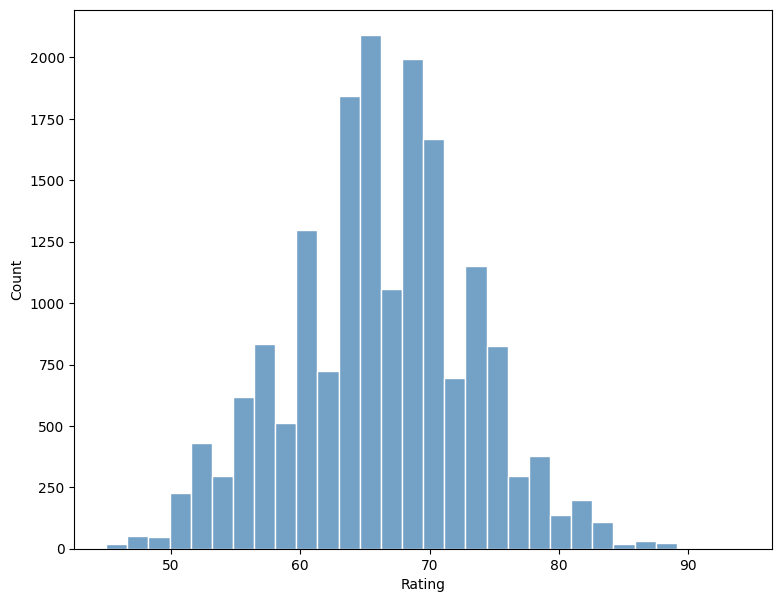

In [9]:
plt.figure(figsize=(9, 7))
sns.histplot(x=df['Rating'], data=df, bins=30, color='steelblue',edgecolor='white')
plt.show()

# Q8. Top 10 clubs ka average Rating barplot banao seaborn se (horizontal)

C:\Users\Sistech Computer\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 131 (\x83) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


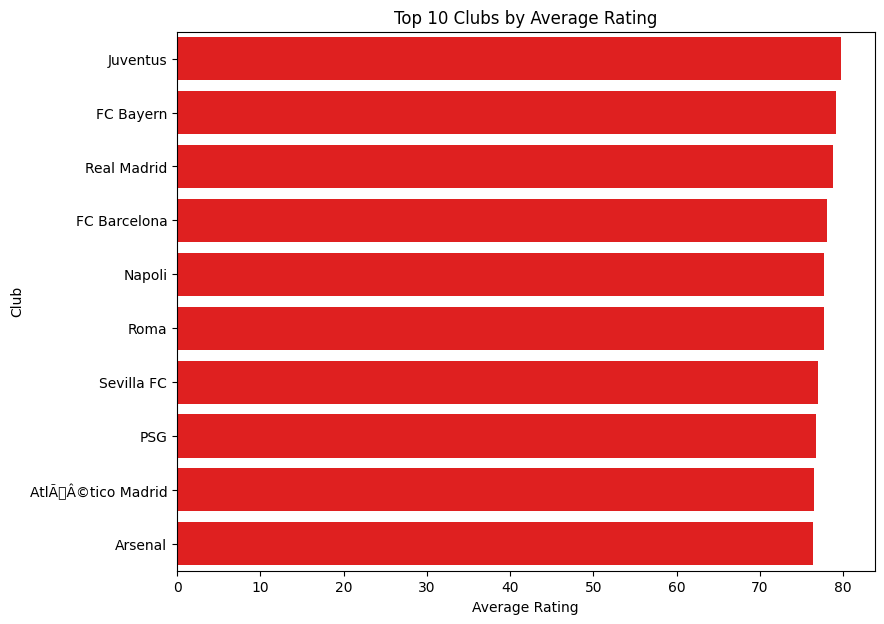

In [17]:
top_10_club_avg_rating = df.groupby('Club')['Rating'].mean().round(2).sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 7))
sns.barplot(x=top_10_club_avg_rating.values, y=top_10_club_avg_rating.index, color='red')
plt.xlabel("Average Rating")
plt.ylabel("Club")
plt.title("Top 10 Clubs by Average Rating")
plt.show()

# Q9. Age vs Rating scatter plot banao, Preffered_Position ke basis par color-coded (seaborn)

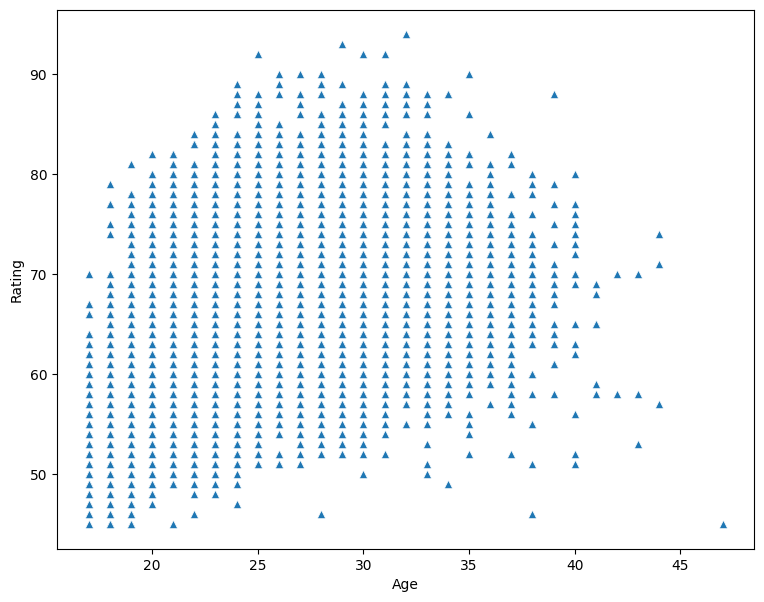

In [24]:
plt.figure(figsize=(9, 7))
sns.scatterplot(x=df['Age'], y=df['Rating'], marker='^')
plt.show()

# Q10. Top 5 nationalities ka pie chart banao matplotlib se player count ke basis par

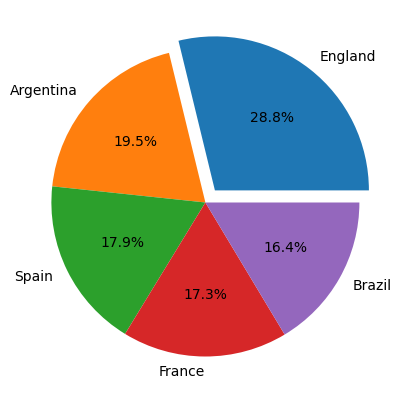

In [32]:
top_5_nationality=df.groupby('Nationality')['Name'].count().sort_values(ascending=False).head(5)

plt.figure(figsize=(5, 5))
plt.pie(x=top_5_nationality.values, labels=top_5_nationality.index, autopct='%1.1f%%', explode=(0.1, 0, 0, 0, 0))
plt.show()